In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import json

In [2]:
import kagglehub
path = kagglehub.dataset_download("datasnaek/youtube-new")

Using Colab cache for faster access to the 'youtube-new' dataset.


In [3]:
raw_us = pd.read_csv(path + "/USvideos.csv")
with open(path + "/US_category_id.json", "r") as f:
    JSON = json.load(f)
raw_ca  = pd.json_normalize(JSON["items"])

In [4]:
raw_us.head(40946)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40941,7UoP9ABJXGE,18.14.06,Dan + Shay - Speechless (Wedding Video),Dan And Shay,10,2018-05-18T04:04:58.000Z,"wedding video|""heartfelt wedding video""|""emoti...",5534278,45128,1591,806,https://i.ytimg.com/vi/7UoP9ABJXGE/default.jpg,False,False,False,Stream + Download:https://wmna.sh/speechlessht...
40942,ju_inUnrLc4,18.14.06,Fifth Harmony - Don't Say You Love Me,FifthHarmonyVEVO,10,2018-05-18T07:00:08.000Z,"fifth hamony|""harmonizers""|""lauren""|""ally""|""no...",23502572,676467,15993,52432,https://i.ytimg.com/vi/ju_inUnrLc4/default.jpg,False,False,False,Fifth Harmony available at iTunes http://smart...
40943,1PhPYr_9zRY,18.14.06,BTS Plays With Puppies While Answering Fan Que...,BuzzFeed Celeb,22,2018-05-18T16:39:29.000Z,"BuzzFeed|""BuzzFeedVideo""|""Puppy Interview""|""pu...",8259128,645888,4052,62610,https://i.ytimg.com/vi/1PhPYr_9zRY/default.jpg,False,False,False,"BTS with the PPS, the puppies. These adorable ..."
40944,BZt0qjTWNhw,18.14.06,The Cat Who Caught the Laser,AaronsAnimals,15,2018-05-18T13:00:04.000Z,"aarons animals|""aarons""|""animals""|""cat""|""cats""...",1685609,38160,1385,2657,https://i.ytimg.com/vi/BZt0qjTWNhw/default.jpg,False,False,False,The Cat Who Caught the Laser - Aaron's Animals


In [5]:
raw_us.isnull().sum()

,0
video_id,0
trending_date,0
title,0
channel_title,0
category_id,0
publish_time,0
tags,0
views,0
likes,0
dislikes,0


In [6]:
top_views = raw_us.sort_values(by="views", ascending=False)
print(top_views[["title", "channel_title", "views"]])


                                                   title        channel_title  \
38547  Childish Gambino - This Is America (Official V...  ChildishGambinoVEVO   
38345  Childish Gambino - This Is America (Official V...  ChildishGambinoVEVO   
38146  Childish Gambino - This Is America (Official V...  ChildishGambinoVEVO   
37935  Childish Gambino - This Is America (Official V...  ChildishGambinoVEVO   
37730  Childish Gambino - This Is America (Official V...  ChildishGambinoVEVO   
...                                                  ...                  ...   
546        Coach Taggart Monday Presser Ahead of Arizona        GoDucksdotcom   
14531                                      Artwork Forge     Palo Alto Online   
14782   1 dead, others injured after Ky. school shooting                Newsy   
14563   1 dead, others injured after Ky. school shooting                Newsy   
14335   1 dead, others injured after Ky. school shooting                Newsy   

           views  
38547  2

In [7]:
categoria_top_views= raw_us.sort_values(by="views", ascending=False)['category_id'].head(10)
categoria_top_views_media = raw_us.sort_values(by="views", ascending=False)['category_id'].mean()

print(f'maiores visualizações por numero da categoirias top 10 \n{categoria_top_views}')

print(f'media de visualizações por numero da categoirias top 10{categoria_top_views_media}')

maiores visualizações por numero da categoirias top 10 
38547    10
38345    10
38146    10
37935    10
37730    10
37531    10
37333    10
37123    10
36913    10
36710    10
Name: category_id, dtype: int64
media de visualizações por numero da categoirias top 1019.97242911914821


In [8]:
raw_ca.head()


,kind,etag,id,snippet.channelId,snippet.title,snippet.assignable
0,youtube#videoCategory,"""m2yskBQFythfE4irbTIeOgYYfBU/Xy1mB4_yLrHy_BmKm...",1,UCBR8-60-B28hp2BmDPdntcQ,Film & Animation,True
1,youtube#videoCategory,"""m2yskBQFythfE4irbTIeOgYYfBU/UZ1oLIIz2dxIhO45Z...",2,UCBR8-60-B28hp2BmDPdntcQ,Autos & Vehicles,True
2,youtube#videoCategory,"""m2yskBQFythfE4irbTIeOgYYfBU/nqRIq97-xe5XRZTxb...",10,UCBR8-60-B28hp2BmDPdntcQ,Music,True
3,youtube#videoCategory,"""m2yskBQFythfE4irbTIeOgYYfBU/HwXKamM1Q20q9BN-o...",15,UCBR8-60-B28hp2BmDPdntcQ,Pets & Animals,True
4,youtube#videoCategory,"""m2yskBQFythfE4irbTIeOgYYfBU/9GQMSRjrZdHeb1OEM...",17,UCBR8-60-B28hp2BmDPdntcQ,Sports,True


In [9]:
categorias = raw_ca[['id','snippet.title']]

In [10]:
categorias.columns = ['category_id', 'category_name']

In [11]:
categorias

,category_id,category_name
0,1,Film & Animation
1,2,Autos & Vehicles
2,10,Music
3,15,Pets & Animals
4,17,Sports
5,18,Short Movies
6,19,Travel & Events
7,20,Gaming
8,21,Videoblogging
9,22,People & Blogs


In [12]:
categorias['category_id'] = categorias['category_id'].astype(int)
mergy = raw_us.merge(categorias, on='category_id')

/tmp/ipython-input-192098597.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  categorias['category_id'] = categorias['category_id'].astype(int)


In [13]:
mergy

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,category_name
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,People & Blogs
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",Entertainment
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...,Comedy
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...,Entertainment
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,Entertainment
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40944,BZt0qjTWNhw,18.14.06,The Cat Who Caught the Laser,AaronsAnimals,15,2018-05-18T13:00:04.000Z,"aarons animals|""aarons""|""animals""|""cat""|""cats""...",1685609,38160,1385,2657,https://i.ytimg.com/vi/BZt0qjTWNhw/default.jpg,False,False,False,The Cat Who Caught the Laser - Aaron's Animals,Pets & Animals
40945,1h7KV2sjUWY,18.14.06,True Facts : Ant Mutualism,zefrank1,22,2018-05-18T01:00:06.000Z,[none],1064798,60008,382,3936,https://i.ytimg.com/vi/1h7KV2sjUWY/default.jpg,False,False,False,NaN,People & Blogs
40946,D6Oy4LfoqsU,18.14.06,I GAVE SAFIYA NYGAARD A PERFECT HAIR MAKEOVER ...,Brad Mondo,24,2018-05-18T17:34:22.000Z,I gave safiya nygaard a perfect hair makeover ...,1066451,48068,1032,3992,https://i.ytimg.com/vi/D6Oy4LfoqsU/default.jpg,False,False,False,I had so much fun transforming Safiyas hair in...,Entertainment
40947,oV0zkMe1K8s,18.14.06,How Black Panther Should Have Ended,How It Should Have Ended,1,2018-05-17T17:00:04.000Z,"Black Panther|""HISHE""|""Marvel""|""Infinity War""|...",5660813,192957,2846,13088,https://i.ytimg.com/vi/oV0zkMe1K8s/default.jpg,False,False,False,How Black Panther Should Have EndedWatch More ...,Film & Animation


In [14]:
mergy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                40949 non-null  object
 1   trending_date           40949 non-null  object
 2   title                   40949 non-null  object
 3   channel_title           40949 non-null  object
 4   category_id             40949 non-null  int64 
 5   publish_time            40949 non-null  object
 6   tags                    40949 non-null  object
 7   views                   40949 non-null  int64 
 8   likes                   40949 non-null  int64 
 9   dislikes                40949 non-null  int64 
 10  comment_count           40949 non-null  int64 
 11  thumbnail_link          40949 non-null  object
 12  comments_disabled       40949 non-null  bool  
 13  ratings_disabled        40949 non-null  bool  
 14  video_error_or_removed  40949 non-null  bool  
 15  de

In [31]:
media_views_por_categoria = mergy.groupby('category_name')['views'].mean().reset_index()
media_views_por_categoria = media_views_por_categoria.sort_values(by='views', ascending=False)

print(f'Média de visualizações por categoria:\n{media_views_por_categoria}')

Média de visualizações por categoria:
            category_name         views
7                   Music  6.201003e+06
4        Film & Animation  3.106250e+06
9   Nonprofits & Activism  2.963884e+06
5                  Gaming  2.620831e+06
3           Entertainment  2.067883e+06
14                 Sports  2.025969e+06
10         People & Blogs  1.531835e+06
1                  Comedy  1.480308e+06
12   Science & Technology  1.452627e+06
0        Autos & Vehicles  1.355965e+06
6           Howto & Style  9.837301e+05
13                  Shows  9.035273e+05
15        Travel & Events  8.546196e+05
11         Pets & Animals  8.311435e+05
2               Education  7.129408e+05
8         News & Politics  5.925877e+05


In [28]:
categoria_top_views= mergy.sort_values(by="views", ascending=False)['category_name'].head(10)
print(f'maiores visualizações por categoirias top 10 \n{categoria_top_views}')



maiores visualizações por categoirias top 10 
38547    Music
38345    Music
38146    Music
37935    Music
37730    Music
37531    Music
37333    Music
37123    Music
36913    Music
36710    Music
Name: category_name, dtype: object


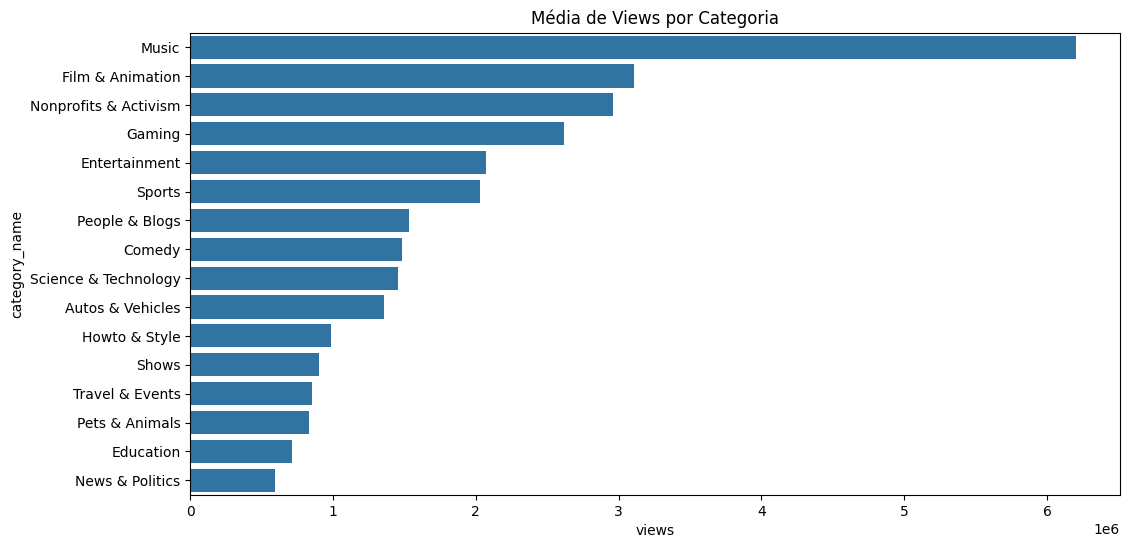

In [33]:
plt.figure(figsize=(12,6))
sns.barplot(data=media_views_por_categoria,
            x='views',
            y='category_name')
plt.title("Média de Views por Categoria")
plt.show()


📈 Correlação likes vs views

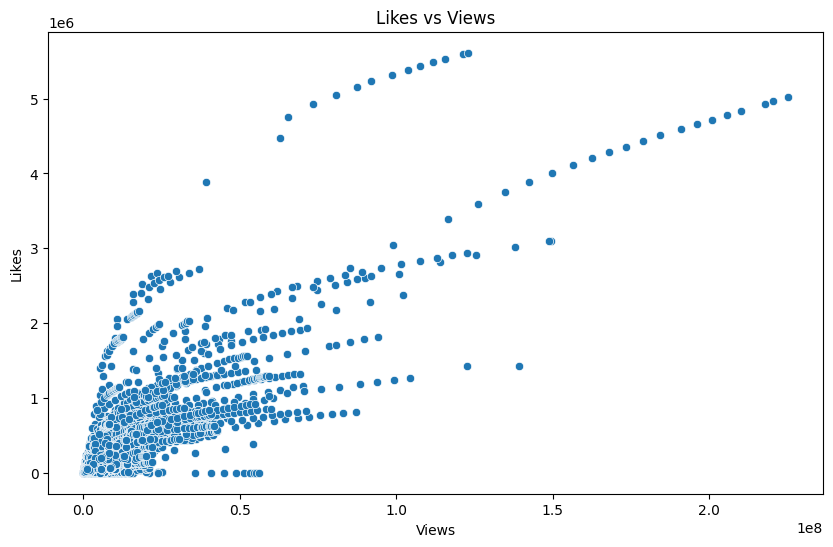

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=raw_us, y='likes', x='views')
plt.xlabel("Views")
plt.ylabel("Likes")
plt.title("Likes vs Views")
plt.show()

In [17]:
print(f'corelação entre views e likes \n {raw_us[["views", "likes"]].corr()}')


corelação entre views e likes 
           views     likes
views  1.000000  0.849177
likes  0.849177  1.000000


In [34]:
mergy['engagement'] = (mergy['likes'] + mergy['comment_count']) / mergy['views']

engagement_categoria = mergy.groupby('category_name')['engagement'].mean().sort_values(ascending=False)

print(engagement_categoria)


category_name
Music                    0.051426
Howto & Style            0.050883
Comedy                   0.049102
People & Blogs           0.046624
Nonprofits & Activism    0.045210
Gaming                   0.044759
Education                0.042267
Pets & Animals           0.037486
Science & Technology     0.034747
Entertainment            0.032427
Film & Animation         0.030981
Shows                    0.025873
Travel & Events          0.024376
Autos & Vehicles         0.020394
News & Politics          0.019112
Sports                   0.017885
Name: engagement, dtype: float64


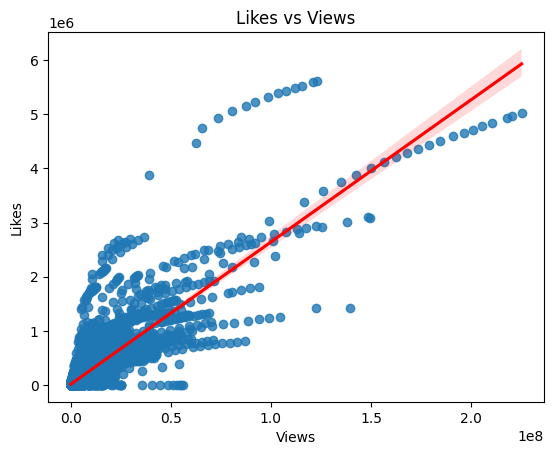

In [39]:
sns.regplot(data=raw_us, x='views', y='likes',line_kws={'color': 'red'})
plt.xlabel("Views")
plt.ylabel("Likes")
plt.title("Likes vs Views")
plt.show()
